# Week 8 - Exercises

## Exercise 1: TF-IDF and the CSS communities.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import json

# load communities
community_df = pd.read_json("week6_communities.json")
comm_dict = dict(zip(community_df["author_id"], community_df["community"]))

# load tokenized abstracts
abstracts = pd.read_json("week7_abstracts_tokenized.json")

# load papers to link abstracts -> authors
papers = pd.read_json("week3_css_papers.json")

# load authors for display names
authors = pd.read_json("week3_css_authors.json")

print(f"Communities: {len(comm_dict)} authors")
print(f"Abstracts: {len(abstracts)}")
print(f"Papers: {len(papers)}")
print(papers.columns.tolist())

Communities: 17802 authors
Abstracts: 47599
Papers: 47599
['id', 'publication_year', 'cited_by_count', 'author_ids']


**TF-IDF explained:**
TF-IDF is a weighting scheme that identifies words that are important to a 
specific document (or group of documents) relative to all documents.

- **TF (term frequency):** how often a word appears in a document. common words 
  in a document get a high TF.
- **IDF (inverse document frequency):** measures how rare a word is across all 
  documents. words that appear in every document get low IDF, while words 
  appearing in only a few documents get high IDF.

TF alone favors generic frequent words. multiplying by IDF downweights words 
that appear everywhere (like "data" or "results") and highlights words that 
are distinctive to a particular document/community.

In [2]:
# assign each paper to communities via its authors
paper_communities = []
for _, row in papers.iterrows():
    comms = set()
    for aid in row["author_ids"]:
        if aid in comm_dict:
            comms.add(comm_dict[aid])
    paper_communities.append(comms)

papers["communities"] = paper_communities

# merge abstracts with papers
abstracts["communities"] = papers["communities"]

# for each community, collect all tokens
# explode so each row is one (abstract, community) pair
abs_exploded = abstracts[["tokens", "communities"]].explode("communities")
abs_exploded = abs_exploded.dropna(subset=["communities"])

print(f"Abstract-community pairs: {len(abs_exploded)}")

# get top 5 communities by author count
comm_sizes = Counter(comm_dict.values())
top5 = [c for c, _ in comm_sizes.most_common(5)]
print(f"Top 5 communities: {top5}")

Abstract-community pairs: 57477
Top 5 communities: [19, 21, 22, 35, 4]


In [3]:
# build a dict: community -> list of all tokens
comm_tokens = {}
for _, row in abs_exploded.iterrows():
    c = int(row["communities"])
    if c not in comm_tokens:
        comm_tokens[c] = []
    comm_tokens[c].extend(row["tokens"])

# check sizes for top 5
for c in top5:
    print(f"Community {c}: {len(comm_tokens.get(c, []))} tokens")

Community 19: 264583 tokens
Community 21: 216578 tokens
Community 22: 274049 tokens
Community 35: 167929 tokens
Community 4: 121624 tokens


In [4]:
# TF = count of word / total words in community document
comm_tf = {}
for c in top5:
    token_counts = Counter(comm_tokens[c])
    total = len(comm_tokens[c])
    comm_tf[c] = {word: count / total for word, count in token_counts.items()}

# top 5 TF words per community
print("Top 5 words by TF per community:\n")
for c in top5:
    top_words = sorted(comm_tf[c].items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"Community {c}: {[(w, f'{tf:.4f}') for w, tf in top_words]}")

Top 5 words by TF per community:

Community 19: [('users', '0.0045'), ('people', '0.0038'), ('work', '0.0037'), ('use', '0.0035'), ('data', '0.0034')]
Community 21: [('model', '0.0061'), ('models', '0.0058'), ('task', '0.0054'), ('data', '0.0040'), ('using', '0.0037')]
Community 22: [('model', '0.0058'), ('image', '0.0050'), ('images', '0.0043'), ('learning', '0.0041'), ('features', '0.0041')]
Community 35: [('study', '0.0045'), ('people', '0.0044'), ('group', '0.0039'), ('social', '0.0039'), ('participants', '0.0038')]
Community 4: [('model', '0.0059'), ('network', '0.0057'), ('networks', '0.0057'), ('find', '0.0044'), ('information', '0.0032')]


In [5]:
# expand to top 9 communities
top9 = [c for c, _ in comm_sizes.most_common(9)]
print(f"Top 9 communities: {top9}")

# IDF = log(N_docs / n_docs_containing_word)
# here "documents" = communities
n_communities = len(comm_tokens)

# which communities contain each word
word_doc_count = Counter()
for c, tokens in comm_tokens.items():
    unique_words = set(tokens)
    for w in unique_words:
        word_doc_count[w] += 1

# compute IDF (using natural log)
idf = {word: np.log(n_communities / count) for word, count in word_doc_count.items()}

# compute TF-IDF for top 9
comm_tfidf = {}
for c in top9:
    if c not in comm_tf:
        token_counts = Counter(comm_tokens[c])
        total = len(comm_tokens[c])
        comm_tf[c] = {word: count / total for word, count in token_counts.items()}
    comm_tfidf[c] = {word: tf * idf.get(word, 0) for word, tf in comm_tf[c].items()}

# print top 10 TF, top 10 TF-IDF, and top 3 authors per community
import networkx as nx

# need degrees from GCC
with open("week4_css_network.json") as f:
    G = nx.node_link_graph(json.load(f))
gcc_nodes = max(nx.connected_components(G), key=len)
GCC = G.subgraph(gcc_nodes)
degrees = dict(GCC.degree())

for c in top9:
    print(f"\n=== Community {c} ({comm_sizes[c]} authors) ===")
    
    # top 10 TF
    top_tf = sorted(comm_tf[c].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"Top 10 TF: {[w for w, _ in top_tf]}")
    
    # top 10 TF-IDF
    top_tfidf = sorted(comm_tfidf[c].items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"Top 10 TF-IDF: {[w for w, _ in top_tfidf]}")
    
    # top 3 authors by degree
    comm_authors = [aid for aid, comm in comm_dict.items() if comm == c]
    top_authors = sorted(comm_authors, key=lambda a: degrees.get(a, 0), reverse=True)[:3]
    author_names = {row["id"]: row["display_name"] for _, row in authors.iterrows()}
    print(f"Top 3 authors: {[author_names.get(a, a) for a in top_authors]}")

Top 9 communities: [19, 21, 22, 35, 4, 3, 10, 8, 24]

=== Community 19 (836 authors) ===
Top 10 TF: ['users', 'people', 'work', 'use', 'data', 'using', 'design', 'online', 'information', 'model']
Top 10 TF-IDF: ['ai', 'robot', 'people', 'users', 'online', 'social', 'hci', 'social_media', 'transactive_memory', 'facebook']
Top 3 authors: ['Michael S. Bernstein', 'Diyi Yang', 'Éric Gilbert']

=== Community 21 (792 authors) ===
Top 10 TF: ['model', 'models', 'task', 'data', 'using', 'tasks', 'text', 'use', 'learning', 'show']
Top 10 TF-IDF: ['nlp', 'text', 'sentence', 'word', 'machine_translation', 'natural_language', 'task', 'coreference', 'qa', 'lexical']
Top 3 authors: ['Dan Jurafsky', 'Chris Callison-Burch', 'Yulia Tsvetkov']

=== Community 22 (750 authors) ===
Top 10 TF: ['model', 'image', 'images', 'learning', 'features', 'network', 'data', 'methods', 'method', 'based']
Top 10 TF-IDF: ['image', 'extensive_experiments', 'images', 'face_recognition', 'video', 'discriminative', 'vqa', '

**TF vs TF-IDF comparison:** the TF lists are dominated by generic words like 
"model", "data", "study" that appear in every community. TF-IDF dramatically 
improves this — each community now has distinctive keywords: community 21 is 
NLP (nlp, sentence, machine_translation), community 22 is computer vision 
(image, face_recognition, vqa), community 35 is social psychology 
(ingroup, social_identity, prejudice), community 3 is epidemics and social 
media (twitter, vaccination, epidemic), etc. IDF makes words more informative 
by downweighting terms that appear across all communities, leaving only the 
words that are unique to each community.

**logarithm base:** we used natural log (ln). the base doesn't matter much — it 
only scales all IDF values by a constant factor, which doesn't change the 
relative ranking of words within a community.

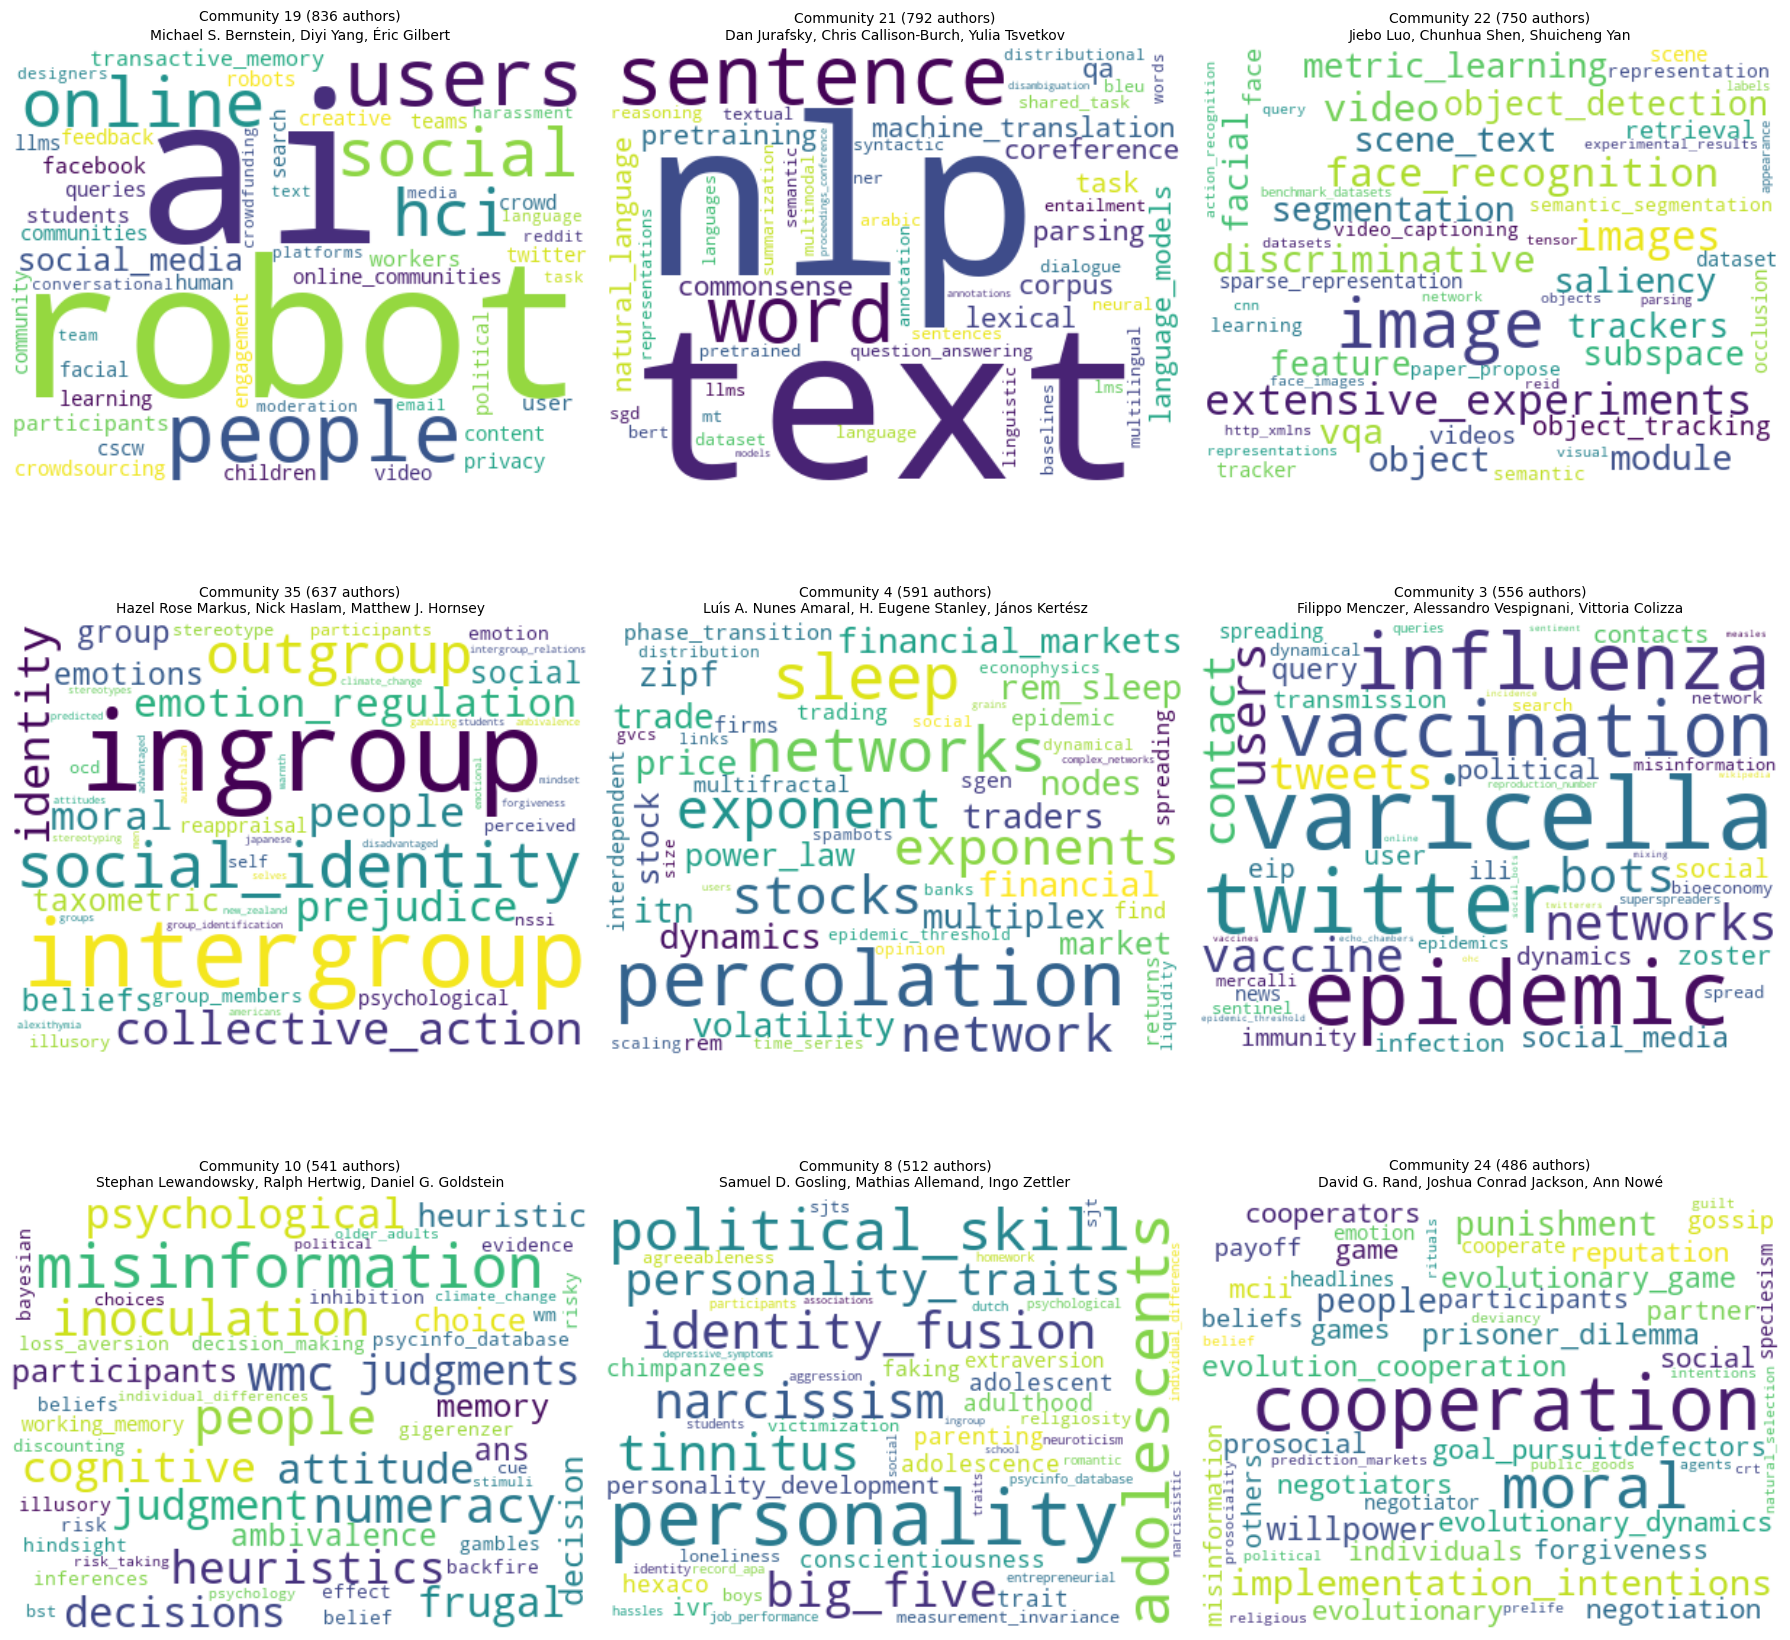

In [6]:
from wordcloud import WordCloud

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
author_names = dict(zip(authors["id"], authors["display_name"]))

for idx, c in enumerate(top9):
    ax = axes[idx // 3][idx % 3]
    
    # use TF-IDF scores as word weights
    wc = WordCloud(width=400, height=300, background_color="white", max_words=50)
    wc.generate_from_frequencies(comm_tfidf[c])
    ax.imshow(wc, interpolation="bilinear")
    
    # top 3 authors
    comm_authors = [aid for aid, comm in comm_dict.items() if comm == c]
    top_authors = sorted(comm_authors, key=lambda a: degrees.get(a, 0), reverse=True)[:3]
    names = [author_names.get(a, "?") for a in top_authors]
    
    ax.set_title(f"Community {c} ({comm_sizes[c]} authors)\n{', '.join(names)}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("week8_wordclouds.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

**Exercise 2 — Community descriptions:**
the wordclouds reveal distinct research subfields within CSS:
- community 19: HCI and AI — robots, users, online communities, social media
- community 21: NLP — text, sentence, machine translation, coreference
- community 22: computer vision — image, face recognition, object detection
- community 35: social psychology — ingroup/outgroup, social identity, prejudice
- community 4: complex systems / econophysics — percolation, financial markets, power law
- community 3: computational epidemiology + social media — vaccination, influenza, twitter
- community 10: cognitive science / misinformation — heuristics, judgment, inoculation
- community 8: personality psychology — big five, narcissism, personality traits
- community 24: cooperation and moral psychology — evolutionary game, prisoner dilemma, punishment

looking up the top authors confirms these findings: dan jurafsky is a leading 
NLP researcher, jiebo luo works in computer vision, filippo menczer studies 
misinformation and social media, samuel gosling is known for personality 
psychology research. the communities make sense.

**Exercise 3 — Has our understanding of CSS changed?**
yes — CSS is much broader than expected. it's not just "social science with 
computers." it spans from hard physics (econophysics, percolation theory) to 
psychology (personality, intergroup relations) to AI/NLP to epidemiology. what 
ties them together is the use of computational methods and large-scale data to 
study human behavior, but the research questions and methods vary enormously 
across communities. the field is really a meeting point for many disciplines 
rather than a single coherent field.